# PART 1) BASIC PRE-PROCESSING

In [49]:
# Let's add all the necessary imports in a unique cell

import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np

from utils.functions import load_and_display, display_single_slice
from sklearn.cluster import KMeans
from skimage.filters import threshold_multiotsu

In [2]:
# os can be used to manage paths to files... these are the paths needed

PROJECT_PATH     = os.path.dirname(os.path.abspath(__name__)) # extract directory of this file
DATA_PATH        = os.path.join(os.getcwd(), "data")
T1_PATH          = os.path.join(DATA_PATH, "T1w.nii")
MASK_PATH        = os.path.join(DATA_PATH, "mask.nii")
FMRI_PATH        = os.path.join(DATA_PATH, "fMRI.nii")
MNI_PATH         = os.path.join(DATA_PATH, "MNI152_T1_2mm_brain.nii")
ATLAS_PATH       = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii")
REGIONS_CSV_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv")

In [3]:
t1_img, t1_hdr, t1_data, t1_dim = load_and_display(T1_PATH, "T1-WEIGHTED", print_info=False)
mask, mask_hdr, mask_data, mask_dims = load_and_display(MASK_PATH, 'MASK', print_info=False)
fmri_img, fmri_hdr, fmri_data, fmri_dims = load_and_display(FMRI_PATH, "FMRI", print_info=False)

## Tissue Segmentation (we will try KMeans and Otsu thresholding), we could also try edge based methods such as canny edge detector + hough

In [50]:
def kmean_segmentation(brain_data, mask, n_cluster, random_state=0, init='auto'):

    kmeans = KMeans(n_clusters=n_cluster, random_state=random_state, n_init=init)
    brain_data = brain_data.reshape(brain_data.shape[0],-1)
    print(brain_data.shape)

    kmeans.fit(brain_data)

    segmented = np.zeros_like(t1_data)
    segmented[mask] = kmeans.labels_
    print(segmented.shape)
    assert len(segmented[mask]) == len(kmeans.labels_), "Il numero di valori non coincide"

    return segmented

def otsu_segmentation(brain_data):

    thresh = threshold_multiotsu(brain_data)
    return thresh

In [43]:
bool_mask = mask_data.astype(bool)
t1_brain = t1_data[bool_mask]

segmented = kmean_segmentation(t1_brain, bool_mask, 2)

(1515051, 1)
(176, 256, 256)


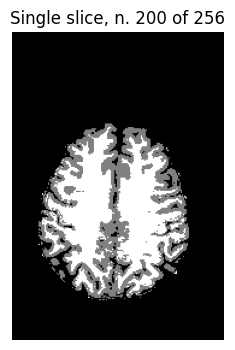

In [64]:

display_single_slice(segmented, slice_idx=200)

(1515051,)


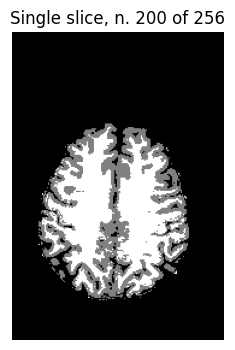

In [63]:
thresh = otsu_segmentation(t1_brain)
regions = np.digitize(t1_brain, bins=thresh)
print(regions.shape)

segmented = np.zeros_like(t1_data)
segmented[bool_mask] = regions

display_single_slice(segmented, slice_idx=200)

In [60]:
print(t1_brain.min(), t1_brain.max())

0.0 901.0
